# Smart Crop Recommendation using AI

This project uses AI and machine learning to analyze soil, weather, and environmental conditions and recommend the most suitable crop for be

# **Import necessary libraries and data**

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pickle

from sklearn.preprocessing import MinMaxScaler

from sklearn.model_selection import train_test_split,GridSearchCV

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier,GradientBoostingClassifier


from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report,ConfusionMatrixDisplay,roc_curve,auc,roc_auc_score,accuracy_score


import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv(r"C:\Neha project\Crop_recommendation5000.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,22,59,23,27,51,4,36.50,mothbeans
1,104,94,51,27,83,5,101.35,banana
2,110,86,54,29,78,5,96.05,banana
3,4,72,20,16,21,5,67.58,kidneybeans
4,28,58,81,17,16,6,93.35,chickpea
...,...,...,...,...,...,...,...,...
4995,112,54,15,25,81,6,76.89,cotton
4996,75,56,18,19,62,5,60.95,maize
4997,10,132,197,15,81,5,74.40,grapes
4998,8,16,6,12,90,7,108.42,orange


In [3]:
df.size

40000

In [4]:
df.columns

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')

In [5]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,51.551800,54.376400,45.384600,25.187600,69.959200,5.922600,111.865034
std,36.362048,30.002372,45.411993,4.993575,22.294935,0.852264,60.172751
min,-1.000000,4.000000,4.000000,8.000000,13.000000,3.000000,19.110000
25%,22.000000,35.000000,21.000000,22.000000,58.000000,5.000000,67.220000
50%,38.000000,54.000000,33.000000,25.000000,80.000000,6.000000,98.555000
75%,84.000000,69.000000,47.000000,28.000000,86.000000,6.000000,150.342500
max,140.000000,145.000000,207.000000,43.000000,100.000000,9.000000,299.040000


In [6]:
df.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [7]:
df.dtypes

N                int64
P                int64
K                int64
temperature      int64
humidity         int64
ph               int64
rainfall       float64
label           object
dtype: object

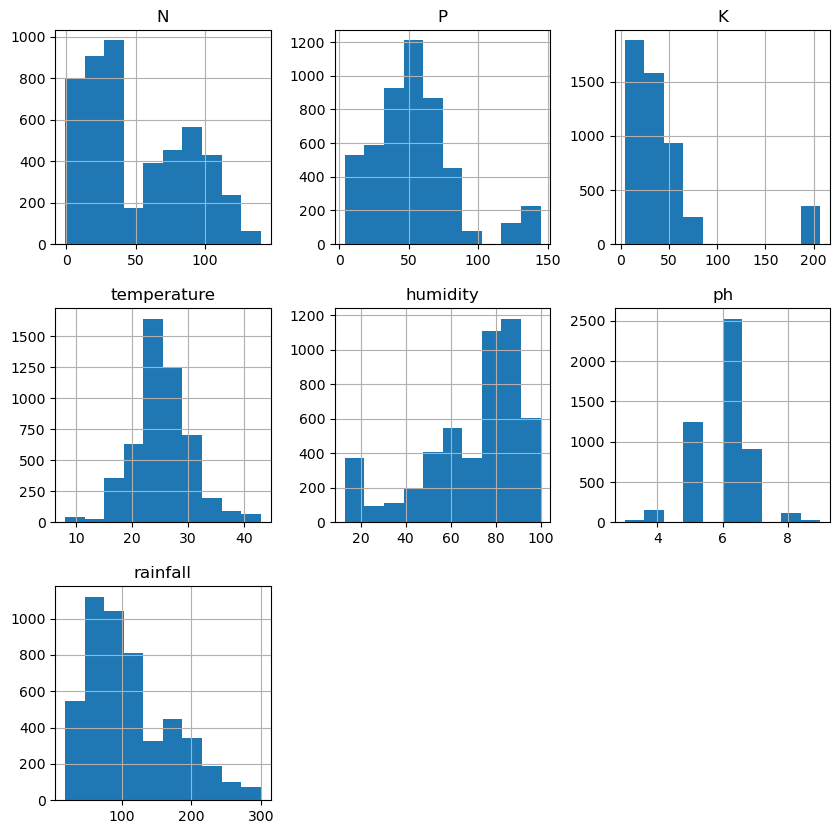

In [8]:
df.hist(figsize=(10,10))
plt.show()

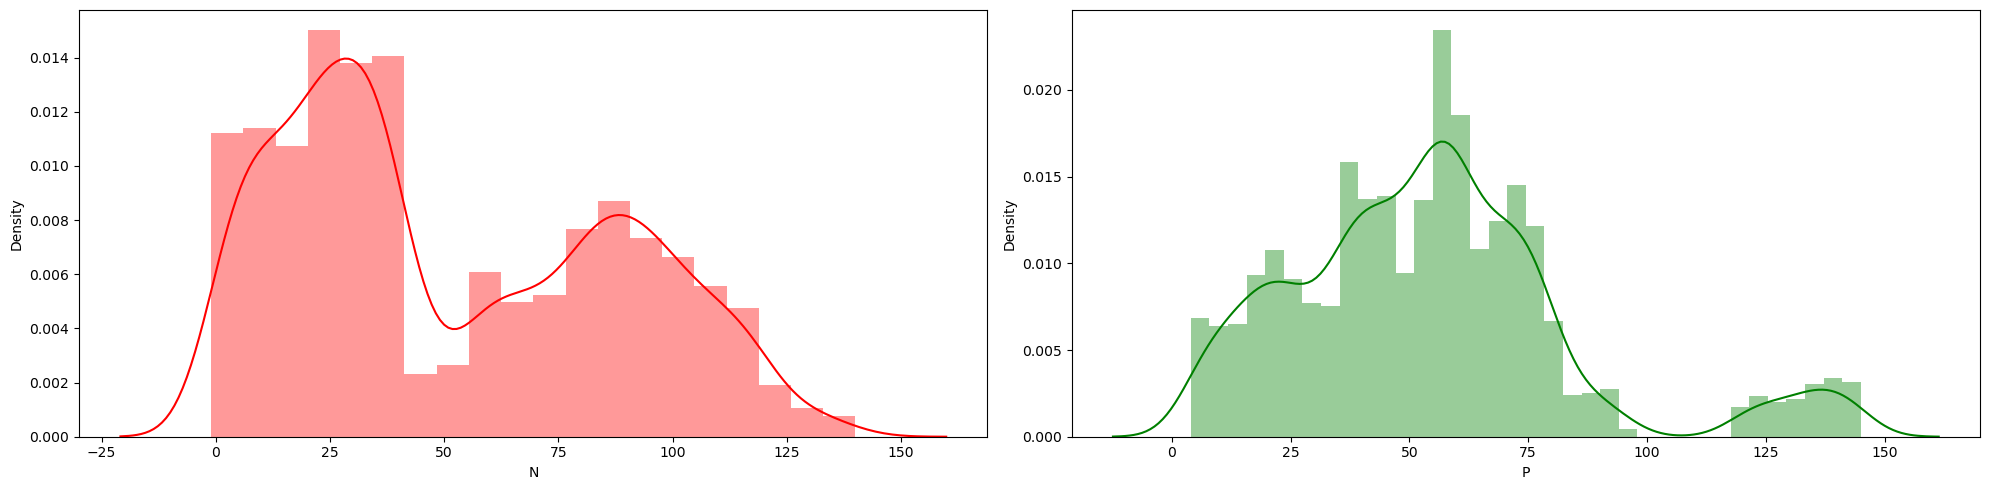

In [12]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['N'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['P'] , color ='green' , ax = ax)
plt.tight_layout()

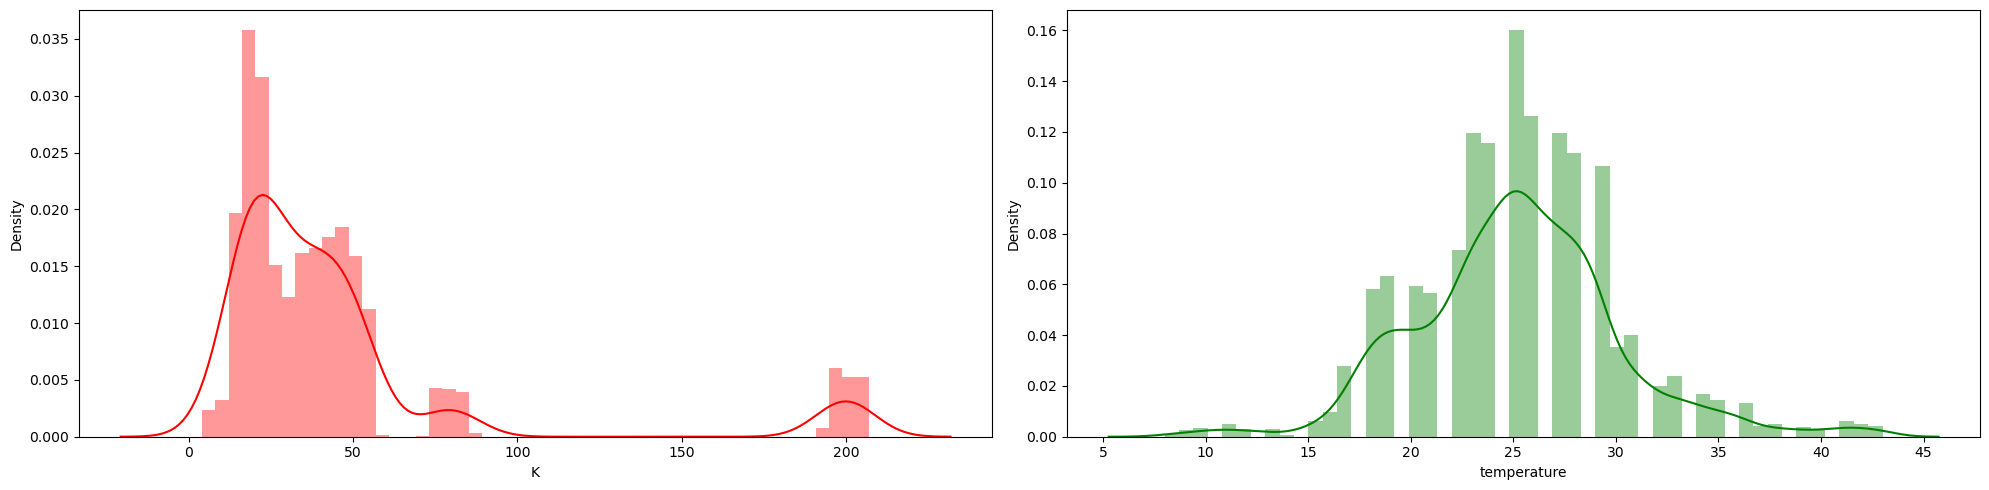

In [13]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['K'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['temperature'] , color ='green' , ax = ax)
plt.tight_layout()

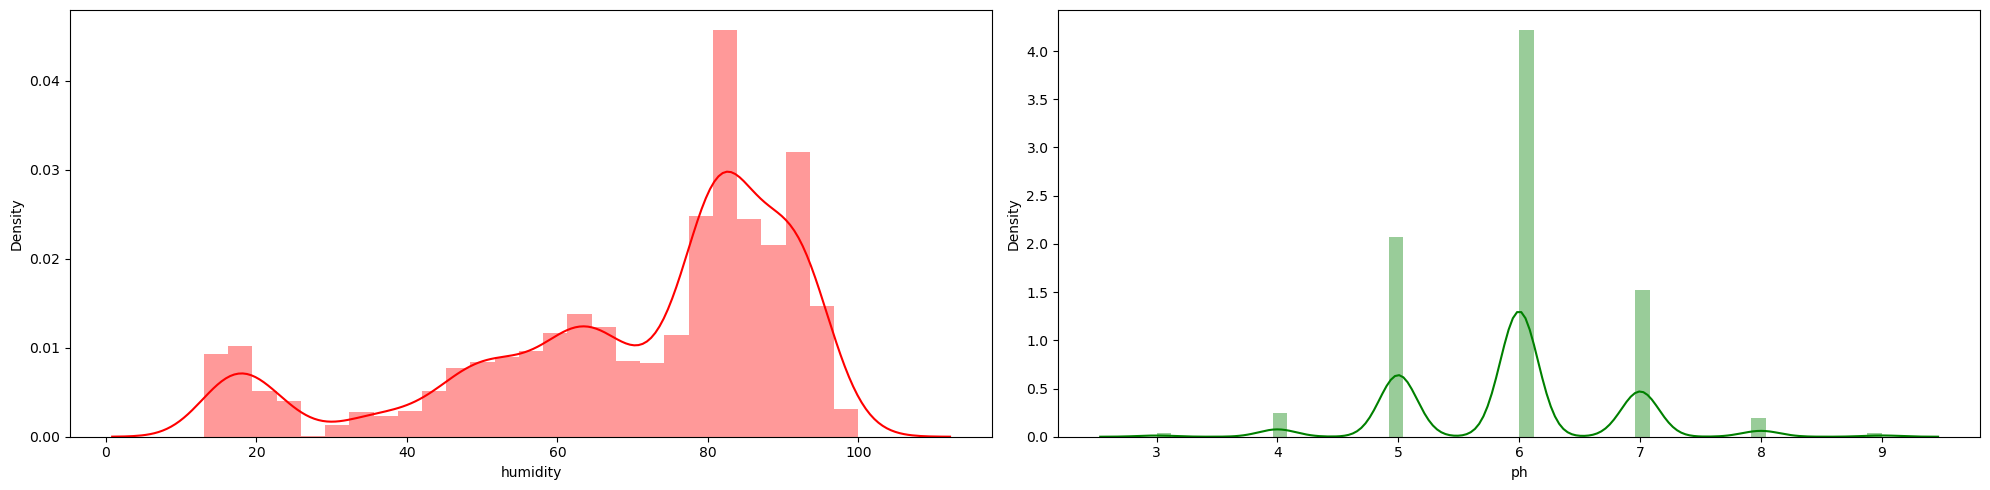

In [14]:
f= plt.figure(figsize=(20,5))
ax=f.add_subplot(121)
sns.distplot(df['humidity'] , color ='red',ax=ax)

ax=f.add_subplot(122)
sns.distplot(df['ph'] , color ='green' , ax = ax)
plt.tight_layout()

<Axes: xlabel='rainfall', ylabel='Density'>

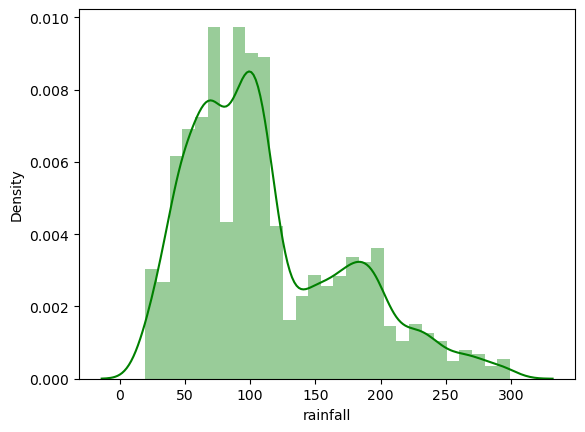

In [16]:
sns.distplot(df['rainfall'] , color ='green')

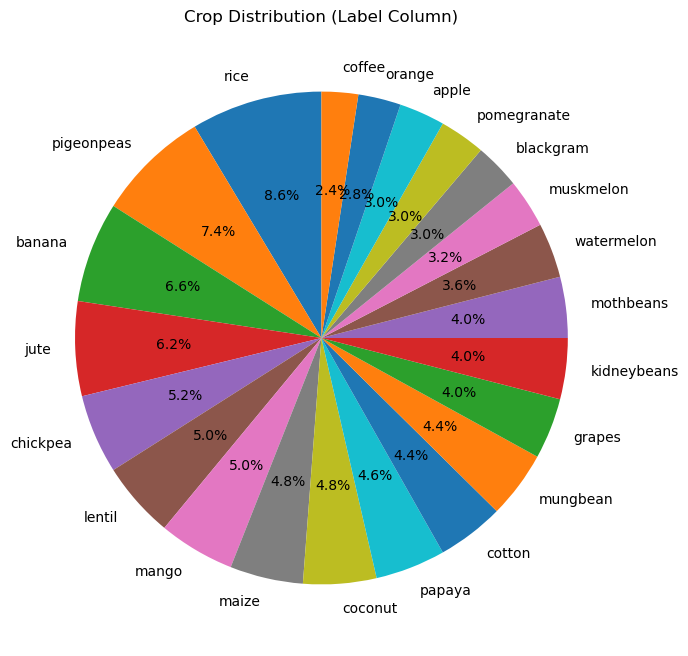

In [18]:
plt.figure(figsize=(8, 8))
df['label'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.ylabel("")
plt.title("Crop Distribution (Label Column)")
plt.show()


In [19]:
x=df.iloc[:,:-1]
x

,N,P,K,temperature,humidity,ph,rainfall
0,22,59,23,27,51,4,36.50
1,104,94,51,27,83,5,101.35
2,110,86,54,29,78,5,96.05
3,4,72,20,16,21,5,67.58
4,28,58,81,17,16,6,93.35
...,...,...,...,...,...,...,...
4995,112,54,15,25,81,6,76.89
4996,75,56,18,19,62,5,60.95
4997,10,132,197,15,81,5,74.40
4998,8,16,6,12,90,7,108.42


In [20]:
y=df.iloc[:,-1]
y

0         mothbeans
1            banana
2            banana
3       kidneybeans
4          chickpea
           ...     
4995         cotton
4996          maize
4997         grapes
4998         orange
4999       chickpea
Name: label, Length: 5000, dtype: object

In [21]:
x.corr()

,N,P,K,temperature,humidity,ph,rainfall
N,1.000000,-0.178227,-0.106147,-0.027463,0.280788,0.101359,0.127783
P,-0.178227,1.000000,0.694613,-0.119277,-0.142136,-0.111445,-0.091543
K,-0.106147,0.694613,1.000000,-0.152760,0.156433,-0.086172,-0.071515
temperature,-0.027463,-0.119277,-0.152760,1.000000,0.217142,-0.063333,-0.029366
humidity,0.280788,-0.142136,0.156433,0.217142,1.000000,0.018426,0.154605
ph,0.101359,-0.111445,-0.086172,-0.063333,0.018426,1.000000,-0.098049
rainfall,0.127783,-0.091543,-0.071515,-0.029366,0.154605,-0.098049,1.000000


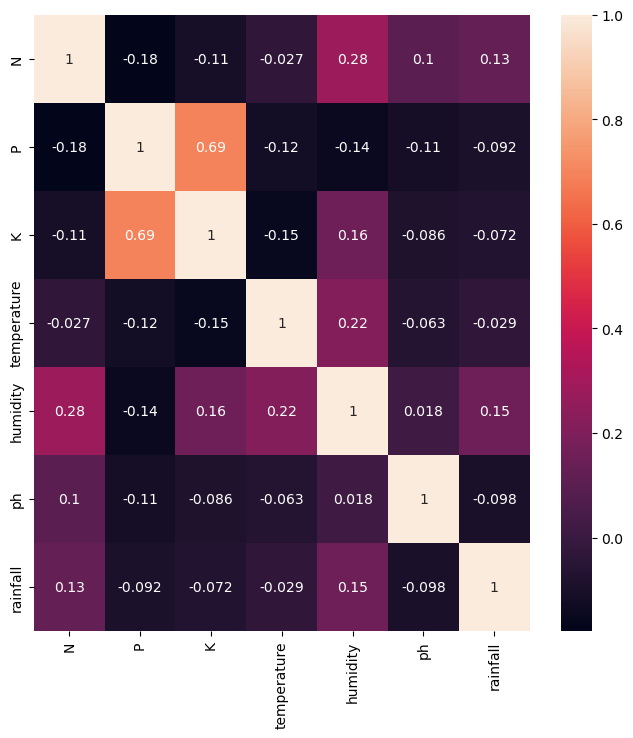

In [22]:
plt.figure(figsize=(8,8))
sns.heatmap(x.corr(), annot=True, cbar=True) #cmap=colormap
plt.show()

In [23]:
m=MinMaxScaler()
x_scale=m.fit_transform(x)
x_scale

array([[0.16312057, 0.39007092, 0.09359606, ..., 0.43678161, 0.16666667,
        0.06212267],
       [0.74468085, 0.63829787, 0.23152709, ..., 0.8045977 , 0.33333333,
        0.29378773],
       [0.78723404, 0.58156028, 0.24630542, ..., 0.74712644, 0.33333333,
        0.27485443],
       ...,
       [0.07801418, 0.90780142, 0.95073892, ..., 0.7816092 , 0.33333333,
        0.19751366],
       [0.06382979, 0.08510638, 0.00985222, ..., 0.88505747, 0.66666667,
        0.31904405],
       [0.24822695, 0.4751773 , 0.36945813, ..., 0.03448276, 0.66666667,
        0.19872825]])

In [24]:
x_train, x_test, y_train, y_test = train_test_split(x_scale, y, test_size=0.3, random_state=42)


In [25]:
x_train.shape,y_train.shape

((3500, 7), (3500,))

In [26]:
x_test.shape,y_test.shape

((1500, 7), (1500,))

In [27]:
k=KNeighborsClassifier(n_neighbors=5)
s=SVC(kernel='rbf')
g=GaussianNB()
d=DecisionTreeClassifier(criterion='entropy')
r=RandomForestClassifier(random_state=1)
a=AdaBoostClassifier()
gr=GradientBoostingClassifier()
lists=[]
l=[k,s,g,d,r,a,gr]
for i in l:
  print(i)
  i.fit(x_train,y_train)
  y_pred=i.predict(x_test)
  lists.append(accuracy_score(y_test,y_pred)*100)
  print(accuracy_score(y_test,y_pred)*100)


  # print(classification_report(y_test,y_pred))

KNeighborsClassifier()
98.6
SVC()
98.13333333333333
GaussianNB()
99.13333333333333
DecisionTreeClassifier(criterion='entropy')
99.26666666666667
RandomForestClassifier(random_state=1)
99.8
AdaBoostClassifier()
22.2
GradientBoostingClassifier()
99.46666666666667


In [28]:
data=pd.DataFrame(lists,index=['KNN','SVC','NB','DECISIONTREE','RANDOMFOREST','ADABOOST','GRADIENT'],columns=['default parameters'])
data

,default parameters
KNN,98.600000
SVC,98.133333
NB,99.133333
DECISIONTREE,99.266667
RANDOMFOREST,99.800000
ADABOOST,22.200000
GRADIENT,99.466667


# Deploy Model

Here the best algorithm is Randomforestclassifier using oversampling with using default parameters.it gives 99% accuracy.so we select the model for deploy.

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        48
      banana       1.00      1.00      1.00        98
   blackgram       1.00      1.00      1.00        33
    chickpea       1.00      1.00      1.00        81
     coconut       1.00      1.00      1.00        74
      coffee       1.00      1.00      1.00        28
      cotton       1.00      1.00      1.00        69
      grapes       1.00      1.00      1.00        55
        jute       1.00      0.98      0.99       103
 kidneybeans       1.00      1.00      1.00        55
      lentil       1.00      0.99      0.99        86
       maize       1.00      1.00      1.00        70
       mango       1.00      1.00      1.00        79
   mothbeans       0.98      1.00      0.99        48
    mungbean       1.00      1.00      1.00        69
   muskmelon       1.00      1.00      1.00        48
      orange       1.00      1.00      1.00        40
      papaya       1.00    

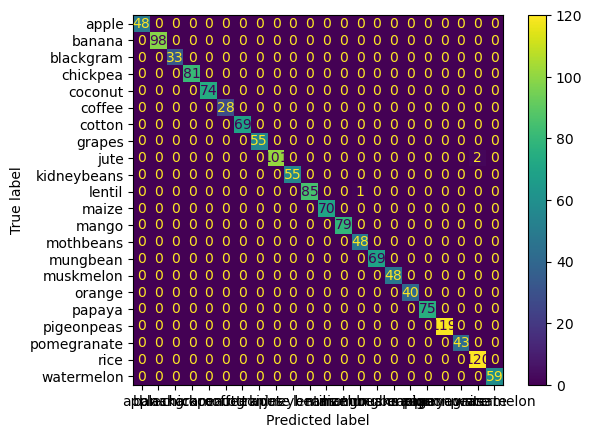

In [29]:
ra=RandomForestClassifier(random_state=1)
ra.fit(x_train,y_train)
y_pred_r=ra.predict(x_test)
print(classification_report(y_test,y_pred_r))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_r))

In [30]:
# auc scores
auc_score = accuracy_score(y_test, y_pred_r)
print(auc_score)

0.998


In [95]:
#pickle.dump(ra,open('crop01','wb'))
#pickle.dump(m,open('scaler01','wb'))